# 1. Data Download

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install python-dotenv
!pip install gdown

import numpy as np
import requests
import time
import os
from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv


##### MAEC dataset:  https://github.com/GeminiLn/EarningsCall_Dataset
# Download MAEC_audio.zip and extract
import gdown
audio_file_id = "1m1GRCHgKn9Vz9IFMC_SpCog6uP3-gFgY"
gdown.download(f"https://drive.google.com/uc?id={audio_file_id}", output="MAEC_audio.zip", quiet=False)
!unzip -q MAEC_audio.zip -d /content/MAEC_audio

##### EC dataset:  https://github.com/Earnings-Call-Dataset/MAEC-A-Multimodal-Aligned-Earnings-Conference-Call-Dataset-for-Financial-Risk-Prediction
# Download all 5 zip files (original dataset parts)
# folder_url = "https://drive.google.com/drive/folders/1BKCANORbcmUJKkOkBOghw6uNHPqS_az1"
# !gdown --folder {folder_url} --output /content/original_zips

# Merge split zip parts into a single zip archive
# Assuming downloaded zip parts are named ACL19_Release.z01, z02, ..., and ACL19_Release.zip
# %cd /content/original_zips
# !zip -s 0 ACL19_Release.zip --out ACL19_Release_All.zip

# Unzip the merged archive
# !unzip -q ACL19_Release_All.zip -d /content/original_dataset


# Go back to default working dir
# %cd /content/drive/MyDrive/Volatility Prediction


# Final paths for use in your code
MAEC_dir = '/content/MAEC_audio/sp1500_earningscall'
original_data_dir = "/content/original_dataset"

Downloading...
From (original): https://drive.google.com/uc?id=1m1GRCHgKn9Vz9IFMC_SpCog6uP3-gFgY
From (redirected): https://drive.google.com/uc?id=1m1GRCHgKn9Vz9IFMC_SpCog6uP3-gFgY&confirm=t&uuid=afb409fe-5cf3-4de5-9a11-9eed23394826
To: /content/MAEC_audio.zip
100%|██████████| 19.6G/19.6G [04:22<00:00, 74.5MB/s]


In [ ]:
import os
import pandas as pd

data = []

# Iterate over all subdirectories
for subdir in os.listdir(MAEC_dir):
    subdir_path = os.path.join(MAEC_dir, subdir)

    if os.path.isdir(subdir_path):
        transcript_path = os.path.join(subdir_path, "text.txt")
        if os.path.exists(transcript_path):
            with open(transcript_path, "r", encoding="utf-8") as f:
                text = f.read()


            data.append({
                "path": transcript_path,
                "text": text,
            })

maec_transcripts_df = pd.DataFrame(data)

maec_transcripts_df.head()

,path,text
0,/content/MAEC_audio/sp1500_earningscall/201608...,"Thank you, Jason, and good morning, everybody...."
1,/content/MAEC_audio/sp1500_earningscall/201511...,"Thank you, [Tyria], and thank you, everyone, f..."
2,/content/MAEC_audio/sp1500_earningscall/201705...,"Thank you, Milton, and good morning everyone\n..."
3,/content/MAEC_audio/sp1500_earningscall/201702...,It's something that our operators do talk abou...
4,/content/MAEC_audio/sp1500_earningscall/201610...,"Thanks, Adnan.\nThese are both good results.\n..."


In [ ]:
def extract_ticker_date(path):
    folder_name = path.split("/")[-2]
    date, ticker = folder_name.split("_", 1)
    ticker = ticker.strip()

    return pd.Series([ticker, date])

maec_transcripts_df[["ticker", "date"]] = maec_transcripts_df["path"].apply(extract_ticker_date)

In [ ]:
maec_transcripts_df.to_csv('maec_transcripts.csv', index=False)

In [ ]:
text_file_paths = []
text_contents = []
for root, dirs, files in os.walk(original_data_dir):
    for file in files:
        if file == "TextSequence.txt":
            file_path = os.path.join(root, file)
            text_file_paths.append(file_path)
            with open(file_path, 'r', encoding='utf-8') as f:
                text_contents.append(f.read())


original_transcripts_df = pd.DataFrame({"transcript_path": text_file_paths, "transcript_text": text_contents})
original_transcripts_df.head()

In [ ]:
def extract_company_date(path):
    folder_name = path.split("/")[-2]
    company, date = folder_name.split("_", 1)
    company = company.strip()
    return pd.Series([company, date])

original_transcripts_df[["company_name", "date"]] = original_transcripts_df["transcript_path"].apply(extract_company_date)

# 2. Add Audio Metadata to Transcript Data

In [ ]:
import pandas as pd

maec_transcripts_df = pd.read_csv('maec_transcripts.csv')


ec_transcripts_df = pd.read_csv('EC_transcripts.csv')
ec_transcripts_df['alpha_transcript_text'] = ec_transcripts_df['alpha_transcript_text'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

ec_transcripts_df.shape

FileNotFoundError: [Errno 2] No such file or directory: 'maec_transcripts.csv'

In [ ]:
from pathlib import Path
maec_transcripts_df['audio_path'] = maec_transcripts_df['path'].apply(lambda p: str(Path(p).parent))

ec_transcripts_df['audio_path'] = ec_transcripts_df['transcript_path'].apply(
    lambda p: str(Path(p).parent / "CEO")
)

In [ ]:
maec_transcripts_df.to_csv('maec_transcripts.csv', index=False)

ec_transcripts_df.to_csv('EC_transcripts.csv', index=False)

In [ ]:
import os
import re
import pandas as pd

def annotate_transcript_with_turns(row):
    transcript_path = row['transcript_path']
    base_dir = os.path.dirname(transcript_path)
    audio_dir = os.path.join(base_dir, 'CEO')

    # If no audio folder, skip
    if not os.path.exists(audio_dir):
        print(f"No audio folder found for: {audio_dir}")
        return None, None

    # Collect audio filenames
    audio_files = [f for f in os.listdir(audio_dir) if f.endswith('.mp3')]
    if not audio_files:
        print(f"No audio files in: {audio_dir}")
        return None, None

    # Extract (turn_number, line_in_turn) pairs
    turn_map = {}
    turn_audio_map = {}

    for f in audio_files:
        match = re.search(r'_(\d+)_(\d+)\.mp3$', f)
        if match:
            turn, line_in_turn = map(int, match.groups())
            turn_map.setdefault(turn, []).append(line_in_turn)
            turn_audio_map.setdefault(turn, []).append((line_in_turn, f))

    # Sort lines in each turn
    for turn in turn_map:
        turn_map[turn] = sorted(turn_map[turn])
        turn_audio_map[turn] = [
            fname for _, fname in sorted(turn_audio_map[turn], key=lambda x: x[0])
        ]

    # Sort original (possibly non-continuous) turns
    sorted_turns = sorted(turn_map.keys())

    # Create continuous numbering: 1, 2, 3, ... in sorted order
    renumber = {old_t: new_t for new_t, old_t in enumerate(sorted_turns, start=1)}

    # Apply renumbering to audio map
    continuous_turn_audio_map = {
        renumber[old_t]: files
        for old_t, files in turn_audio_map.items()
    }

    # Read transcript lines
    try:
        with open(transcript_path, 'r', encoding='utf-8') as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
    except Exception as e:
        print(f"Failed to read transcript: {transcript_path}, error: {e}")
        return None, None

    # Annotate transcript lines
    annotated_lines = []
    line_idx = 0

    for old_t in sorted_turns:
        new_t = renumber[old_t]
        line_count = len(turn_map[old_t])

        for _ in range(line_count):
            if line_idx < len(lines):
                annotated_lines.append(f"[TURN {new_t}] {lines[line_idx]}")
                line_idx += 1

    # Add remaining lines (if transcript longer)
    while line_idx < len(lines):
        annotated_lines.append(f"[TURN ?] {lines[line_idx]}")
        line_idx += 1

    annotated_text = "\n".join(annotated_lines)

    return annotated_text, continuous_turn_audio_map



annotations = ec_transcripts_df.apply(annotate_transcript_with_turns, axis=1, result_type='expand')
ec_transcripts_df['annotated_transcript_text'] = annotations[0]
ec_transcripts_df['turn_audio_map'] = annotations[1]

ec_transcripts_df.to_csv('EC_transcripts.csv', index=False)

print("\n===== Sample Annotated Transcript =====")
print(ec_transcripts_df.iloc[0]['annotated_transcript_text'])
print("\n===== Sample Turn → Audio Map =====")
print(ec_transcripts_df.iloc[0]['turn_audio_map'])

In [ ]:
import os
import re
import pandas as pd

def annotate_maec_transcript_with_turns(row):
    transcript_path = row['path']
    audio_dir = os.path.dirname(transcript_path)

    # If no audio folder, skip
    if not os.path.exists(audio_dir):
        print(f"No audio folder found for: {audio_dir}")
        return None, None

    # Collect audio filenames
    audio_files = [f for f in os.listdir(audio_dir) if f.endswith('.mp3')]
    if not audio_files:
        print(f"No audio files in: {audio_dir}")
        return None, None

    # Extract (turn_number, line_in_turn) pairs
    turn_map = {}        # turn → list of line numbers
    turn_audio_map = {}  # turn → list of unordered (line_in_turn, filename)

    for f in audio_files:
        # Example: ESE_20160503_f000031101.mp3
        match = re.search(r'_f0*([0-9]{3})([0-9]{3})\.mp3$', f)
        if match:
            turn = int(match.group(1))       # '031' → 31
            line_code = int(match.group(2))  # '101' → 101
            line_in_turn = (line_code - 100) + 1

            turn_map.setdefault(turn, []).append(line_in_turn)
            turn_audio_map.setdefault(turn, []).append((line_in_turn, f))

    if not turn_map:
        print(f"No valid turn info: {audio_dir}")
        return None, None

    # Sort lines within each turn
    for turn in turn_map:
        turn_map[turn] = sorted(turn_map[turn])
        turn_audio_map[turn] = [
            fname for _, fname in sorted(turn_audio_map[turn], key=lambda x: x[0])
        ]

    # Sort turns
    sorted_turns = sorted(turn_map.keys())

    # Create continuous turn numbering
    renumber = {old_t: new_t for new_t, old_t in enumerate(sorted_turns, start=1)}

    # Renumber the audio map keys
    continuous_turn_audio_map = {
        renumber[old_t]: files
        for old_t, files in turn_audio_map.items()
    }

    # Read transcript lines
    try:
        with open(transcript_path, 'r', encoding='utf-8') as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
    except Exception as e:
        print(f"Failed to read transcript: {transcript_path}, error: {e}")
        return None, None

    # Annotate transcript lines using new turn ids
    annotated_lines = []
    line_idx = 0

    for old_t in sorted_turns:
        new_t = renumber[old_t]
        line_count = len(turn_map[old_t])

        for _ in range(line_count):
            if line_idx < len(lines):
                annotated_lines.append(f"[TURN {new_t}] {lines[line_idx]}")
                line_idx += 1

    # Leftover lines
    while line_idx < len(lines):
        annotated_lines.append(f"[TURN ?] {lines[line_idx]}")
        line_idx += 1

    annotated_text = "\n".join(annotated_lines)

    return annotated_text, continuous_turn_audio_map

annotations = maec_transcripts_df.apply(
    annotate_maec_transcript_with_turns,
    axis=1,
    result_type='expand'
)

maec_transcripts_df['annotated_transcript_text'] = annotations[0]
maec_transcripts_df['turn_audio_map'] = annotations[1]

maec_transcripts_df.to_csv(
    'maec_transcripts.csv',
    index=False
)

In [ ]:
maec_transcripts_df.head(2)

,path,text,ticker,date,audio_path,annotated_transcript_text,turn_audio_map
0,/content/MAEC_audio/sp1500_earningscall/201608...,"Thank you, Jason, and good morning, everybody....",AVA,20160803,/content/MAEC_audio/sp1500_earningscall/201608...,"[TURN 1] Thank you, Jason, and good morning, e...","{3: ['AVA_20160803_f000008100.mp3', 'AVA_20160..."
1,/content/MAEC_audio/sp1500_earningscall/201511...,"Thank you, [Tyria], and thank you, everyone, f...",PLUS,20151104,/content/MAEC_audio/sp1500_earningscall/201511...,"[TURN 1] Thank you, [Tyria], and thank you, ev...","{1: ['PLUS_20151104_f000002100.mp3', 'PLUS_201..."


# 3. Generate Questions

## MAEC

In [ ]:
import pandas as pd

maec_transcripts_df = pd.read_csv('maec_transcripts.csv')

import ast

maec_transcripts_df['turn_audio_map'] = maec_transcripts_df['turn_audio_map'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


maec_transcripts_df.shape

(3443, 7)

In [ ]:
def linear_partition(seq, k):
    """
    Partition seq (list of positive ints) into k contiguous partitions
    minimizing the maximum partition sum. Returns list of partitions (lists).
    Standard DP solution.
    """
    n = len(seq)
    if k <= 0:
        return []
    if k >= n:
        # each element in its own partition (or empty partitions appended)
        return [[x] for x in seq] + [[] for _ in range(k - n)]

    # prefix sums
    prefix = [0] * (n + 1)
    for i in range(1, n + 1):
        prefix[i] = prefix[i-1] + seq[i-1]

    # DP tables
    M = [[0] * (k + 1) for _ in range(n + 1)]
    D = [[0] * (k + 1) for _ in range(n + 1)]

    # base cases
    for i in range(1, n + 1):
        M[i][1] = prefix[i]
    for j in range(1, k + 1):
        M[1][j] = seq[0]

    # fill DP
    for i in range(2, n + 1):
        for j in range(2, k + 1):
            best = None
            best_x = None
            # try partition point x between 1..i-1
            for x in range(1, i):
                cost = max(M[x][j-1], prefix[i] - prefix[x])
                if best is None or cost < best:
                    best = cost
                    best_x = x
            M[i][j] = best
            D[i][j] = best_x

    # reconstruct partitions
    partitions = []
    def reconstruct(n, k):
        if k == 1:
            partitions.append(seq[:n])
        else:
            x = D[n][k]
            reconstruct(x, k-1)
            partitions.append(seq[x:n])
    reconstruct(n, k)
    return partitions




import re
import math



# pattern to capture each transcript line that starts with [TURN X]
LINE_PATTERN = re.compile(r"^\[TURN\s+(\d+)\]\s*(.*)$", re.MULTILINE)

def split_ecc_into_chunks(transcript_text, turn_audio_map, max_lines=100):
    """
    Parse transcript into turns with aligned audio files,
    then divide into balanced chunks using linear partition,
    ensuring turns are not split.
    """

    # Extract turns (with aligned audio)
    matches = LINE_PATTERN.findall(transcript_text)
    if not matches:
        return []

    turns = []
    current_tid = None
    current_lines = []

    for tid_str, text in matches:
        tid = int(tid_str)
        full_line = f"[TURN {tid}] {text.strip()}"

        if tid == current_tid:
            current_lines.append(full_line)
        else:
            # finalize previous turn
            if current_tid is not None:
                audio_files = turn_audio_map.get(current_tid, [])
                if len(audio_files) >= len(current_lines):
                    audio_files = audio_files[:len(current_lines)]
                else:
                    audio_files = audio_files + [None] * (len(current_lines) - len(audio_files))

                turns.append({
                    "turn_id": current_tid,
                    "lines": current_lines,
                    "audio_files": audio_files
                })

            current_tid = tid
            current_lines = [full_line]

    # finalize last turn
    if current_tid is not None:
        audio_files = turn_audio_map.get(current_tid, [])
        if len(audio_files) >= len(current_lines):
            audio_files = audio_files[:len(current_lines)]
        else:
            audio_files = audio_files + [None] * (len(current_lines) - len(audio_files))

        turns.append({
            "turn_id": current_tid,
            "lines": current_lines,
            "audio_files": audio_files
        })

    # Compute target number of chunks
    total_lines = sum(len(t["lines"]) for t in turns)
    num_chunks = max(1, math.ceil(total_lines / max_lines))

    # Linear partition on turn sizes
    turn_sizes = [len(t["lines"]) for t in turns]   # e.g. [5, 17, 9, 33, ...]

    partitions = linear_partition(turn_sizes, num_chunks)
    # partitions is list of lists, each a sequence of turn sizes

    # Build final chunks
    final_chunks = []
    turn_index = 0

    for part in partitions:
        part_turns = turns[turn_index : turn_index + len(part)]
        turn_index += len(part)

        chunk_lines = []
        chunk_audio_map = {}
        line_number = 1

        for turn in part_turns:
            for i, line in enumerate(turn["lines"]):
                chunk_lines.append(line)
                if i < len(turn["audio_files"]):
                    chunk_audio_map[line_number] = turn["audio_files"][i]
                line_number += 1

        final_chunks.append({
            "text_lines": chunk_lines,
            "audio_map": chunk_audio_map
        })

    return final_chunks

In [ ]:
all_ecc_chunks = []

for idx, row in maec_transcripts_df.iterrows():
    transcript = row["annotated_transcript_text"]
    turn_audio_map = row["turn_audio_map"]

    chunks = split_ecc_into_chunks(transcript, turn_audio_map, max_lines=100)
    all_ecc_chunks.append({
        "ecc_id": idx,
        "chunks": chunks
    })

In [ ]:
import os
import json
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

BATCH_FILE = "batch.jsonl"


template_developer_prompt = """
System: System: You are a financial analysis assistant.

Your role is to extract Q&A pairs from an Earnings Conference Call (ECC) excerpt.

--------------------------------------------
## REQUIREMENTS
--------------------------------------------
### QUESTION
- Formulate a general financial concept question that could influence stock volatility.
- Requirements:
  - Be abstract, high-level, concise, and focus on a single theme.
  - Avoid multi-part or combined questions.
  - Exclude:
    - Company names
    - Product names
    - Unique technologies
    - Customer identifiers
    - Any specifics (these belong only in answers)
  - Ensure questions remain conceptual and generalized.

### ANSWER
- Answers must be strictly grounded in the ECC excerpt using explicit details:
  - Include numbers, timeframes, or operational commentary as provided.
  - Do not fabricate, infer, or paraphrase beyond the text.
  - Directly address the generalized question.
- Append to each answer:
  source_lines: [start_line, end_line]

### EXCLUSIONS
- Omit greetings, thank-you statements, or introductions.
- Exclude legal disclaimers, operator prompts, procedural text, and irrelevant minutiae not affecting stock volatility.
- Entity names are prohibited in questions; include them in answers only if present in the excerpt.

--------------------------------------------
## OUTPUT FORMAT
--------------------------------------------
For each Q&A pair, use the format:

Q: <generalized, conceptual question>
A: <specific, evidence-based answer from the excerpt>
source_lines: [start_line, end_line]

If the excerpt contains no volatility-relevant content, output exactly:

[]
""".strip()



with open(BATCH_FILE, "w", encoding="utf-8") as f:

    for ecc in all_ecc_chunks:
        ecc_id = ecc["ecc_id"]
        if ecc_id not in [2051, 6, 2055, 2057, 10, 2060, 17]:
            continue


        for chunk_id, chunk in enumerate(ecc["chunks"]):

            # Build numbered chunk
            numbered_chunk = "\n".join(
                f"{idx}: {line}" for idx, line in enumerate(chunk["text_lines"], start=1)
            )

            # Refined USER prompt

            user_prompt = f"""
            Here is an ECC excerpt with numbered lines:

            {numbered_chunk}

            Apply the instructions from the developer message.
            Return the output in strict JSON format as specified earlier.
            If the excerpt contains nothing relevant to stock volatility, return [].
            """.strip()

            body = {
                "model": "gpt-5",
                "reasoning": {"effort": "low"},
                "instructions": template_developer_prompt,
                "input": user_prompt
            }

            # Responses endpoint
            entry = {
                "custom_id": f"{ecc_id}-{chunk_id}",
                "method": "POST",
                "url": "/v1/responses",
                "body": body
            }

            f.write(json.dumps(entry, ensure_ascii=False) + "\n")


print(f"Batch JSONL created: {BATCH_FILE}")

Batch JSONL created: batch.jsonl


In [ ]:
import json
import time
from openai import OpenAI

#    UPLOAD batch file

upload = client.files.create(
    file=open(BATCH_FILE, "rb"),
    purpose="batch"
)

file_id = upload.id
print("Uploaded batch file:", file_id)

while True:
    status = client.files.retrieve(file_id).status
    print("File status:", status)
    if status == "processed":
        break
    time.sleep(3)



#   CREATE BATCH JOB
#

batch = client.batches.create(
    input_file_id=file_id,
    endpoint="/v1/responses",
    completion_window="24h"
)

batch_id = batch.id
print("Batch job created:", batch_id)

while True:
    info = client.batches.retrieve(batch_id)
    print(
        f"Batch status: {info.status} "
        f"({info.request_counts.completed}/{info.request_counts.total})"
    )

    if info.status == "completed":
        break
    if info.status in ("failed", "expired"):
        raise RuntimeError("Batch job failed or expired.")
    time.sleep(30)



#   DOWNLOAD AND PARSE RESULTS


output_file_id = info.output_file_id
result_file = client.files.content(output_file_id)
result_text = result_file.text

qa_results = {}
prompt_tokens_list = {}
completion_tokens_list = {}
reasoning_tokens_list = {}
total_tokens_list = {}

for line in result_text.splitlines():
    obj = json.loads(line)
    cid = obj["custom_id"]

    response = obj["response"]["body"]

    assistant_text = None
    for item in response.get("output", []):
        if item.get("type") == "message":
            content_list = item.get("content", [])
            if content_list and "text" in content_list[0]:
                assistant_text = content_list[0]["text"].strip()
            break

    qa_results[cid] = assistant_text

    usage = response.get("usage", {})
    prompt_tokens = usage.get("input_tokens", 0)
    completion_tokens = usage.get("output_tokens", 0)
    reasoning_tokens = usage.get("output_tokens_details", {}).get("reasoning_tokens", 0)
    total_tokens = prompt_tokens + completion_tokens

    prompt_tokens_list[cid] = prompt_tokens
    completion_tokens_list[cid] = completion_tokens
    reasoning_tokens_list[cid] = reasoning_tokens
    total_tokens_list[cid] = total_tokens

    print(
        f"ID {cid}: prompt={prompt_tokens}, completion={completion_tokens}, "
        f"reasoning={reasoning_tokens}, total={total_tokens}"
    )



first_key = list(qa_results.keys())[0]
print("\nSample output for ID =", first_key)
print(qa_results[first_key])

Uploaded batch file: file-1j3wAxsXz1MjXPDQPgeKfV
File status: processed
Batch job created: batch_6a784e461f98819095ffc5f7fde9aad4
Batch status: validating (0/0)
Batch status: validating (0/0)
Batch status: validating (0/0)
Batch status: in_progress (4/8)
Batch status: in_progress (4/8)
Batch status: completed (8/8)
ID 6-0: prompt=1918, completion=1148, reasoning=576, total=3066
ID 10-0: prompt=2610, completion=2622, reasoning=1920, total=5232
ID 10-1: prompt=2152, completion=1818, reasoning=1280, total=3970
ID 17-0: prompt=1736, completion=1804, reasoning=1152, total=3540
ID 2051-0: prompt=2481, completion=1482, reasoning=832, total=3963
ID 2055-0: prompt=2265, completion=1619, reasoning=1024, total=3884
ID 2057-0: prompt=1542, completion=1886, reasoning=1344, total=3428
ID 2060-0: prompt=1384, completion=1684, reasoning=1152, total=3068

Sample output for ID = 6-0
[
  {
    "Q": "What is the outlook for amortization expenses in the near term?",
    "A": "For the second half of the yea

In [ ]:
import json

with open("maec_raw_chunks_qas_results.json", "w", encoding="utf-8") as f:
    json.dump(qa_results, f, ensure_ascii=False, indent=2)


with open("maec_raw_chunks_qas_results.json", "r", encoding="utf-8") as f:
    qas = json.load(f)

In [ ]:
import ast
import re

def normalize_qa_dict(d):
    """Normalize QA dict keys to exactly Q / A / source_lines"""
    q = (
        d.get("Q")
        or d.get("q")
        or d.get("question")
        or d.get("Question")
    )
    a = (
        d.get("A")
        or d.get("a")
        or d.get("answer")
        or d.get("Answer")
    )

    if not q or not a:
        return None

    out = {"Q": q.strip(), "A": a.strip()}

    if "source_lines" in d:
        out["source_lines"] = d["source_lines"]

    return out


def parse_qa_value(qa_key, qa_val):
    # Case 1: already a list
    if isinstance(qa_val, list):
        qas = []
        for d in qa_val:
            if isinstance(d, dict):
                norm = normalize_qa_dict(d)
                if norm:
                    qas.append(norm)
                else:
                    print(f"[WARN] {qa_key}: dropped malformed QA → {d}")
        return qas

    # Case 2: not a string
    if not isinstance(qa_val, str):
        print(f"[WARN] {qa_key}: unsupported type {type(qa_val)}")
        return []

    # Normalize text
    text = qa_val.replace("\\$", "$").strip()

    # Case 3: list-like string
    if text.startswith("["):
        try:
            raw = ast.literal_eval(text)
            qas = []
            for d in raw:
                if isinstance(d, dict):
                    norm = normalize_qa_dict(d)
                    if norm:
                        qas.append(norm)
                    else:
                        print(f"[WARN] {qa_key}: dropped malformed QA → {d}")
            return qas
        except Exception as e:
            print(f"[WARN] {qa_key}: literal_eval failed → {e}")
            return []

    qas = []
    current = None
    mode = None  # "Q" or "A"

    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue

        lower = line.lower()

        # Question markers
        if lower.startswith(("q:", "question:")):
            current = {"Q": line.split(":", 1)[1].strip()}
            mode = "Q"

        # Answer markers
        elif lower.startswith(("a:", "answer:")):
            if not current:
                print(f"[WARN] {qa_key}: A without Q")
                continue
            current["A"] = line.split(":", 1)[1].strip()
            mode = "A"

        # source_lines
        elif lower.startswith("source_lines"):
            if not current:
                print(f"[WARN] {qa_key}: source_lines without QA")
                continue

            nums = re.findall(r"\d+", line)
            if len(nums) >= 2:
                current["source_lines"] = [int(nums[0]), int(nums[1])]
            else:
                print(f"[WARN] {qa_key}: bad source_lines → {line}")

            if "Q" in current and "A" in current:
                qas.append(current)
            else:
                print(f"[WARN] {qa_key}: incomplete QA → {current}")

            current = None
            mode = None

        # Multiline continuation
        else:
            if current and mode:
                current[mode] += " " + line

    if current:
        print(f"[WARN] {qa_key}: dangling QA at end → {current}")

    return qas

In [ ]:
total_qas = 0

ecc_qas = dict()

for qa_key, qa_val in qas.items():
    qa_list = parse_qa_value(qa_key, qa_val)
    ecc_qas[qa_key] = qa_list
    total_qas += len(qa_list)

print("Total number of QAs:", total_qas)

for k, v in ecc_qas.items():
    for qa_dict in v:
        if 'Q' not in qa_dict or 'A' not in qa_dict:
            print(f"Key: {k}, Problematic QA dictionary: {qa_dict.keys()}")

Total number of QAs: 49


In [ ]:
import json

with open("maec_clean_chunks_qas_results.json", "w", encoding="utf-8") as f:
    json.dump(ecc_qas, f, ensure_ascii=False, indent=2)

In [ ]:
for key, qas in ecc_qas.items():
    ecc_id_str, chunk_id_str = key.split("-")
    ecc_id = int(ecc_id_str)
    chunk_id = int(chunk_id_str)
    all_ecc_chunks[ecc_id]['chunks'][chunk_id]['qas'] = qas

import json

with open("maec_ecc_chunks_with_qas.json", "w", encoding="utf-8") as f:
    json.dump(all_ecc_chunks, f, ensure_ascii=False, indent=2)

## EC (KeFVP Test Set)

In [ ]:
!wget -O ec_test_avg_val.csv \
https://raw.githubusercontent.com/hankniu01/KeFVP/main/price_data/test_split_Avg_Series_WITH_LOG.csv

import pandas as pd

ec_test_avg_val_df = pd.read_csv('ec_test_avg_val.csv')

In [ ]:
# Make both date columns strings
ec_test_avg_val_df = ec_test_avg_val_df.copy()

ec_test_avg_val_df["date"] = pd.to_datetime(
    ec_test_avg_val_df[["year", "month", "day"]]
).dt.strftime("%Y%m%d")

ec_transcripts_df = ec_transcripts_df.copy()
ec_transcripts_df["date"] = ec_transcripts_df["date"].astype(str)

test_keys = (
    ec_test_avg_val_df[["name", "date"]]
    .rename(columns={"name": "company_name"})
    .drop_duplicates()
)

ec_transcripts_test_df = ec_transcripts_df.merge(
    test_keys,
    on=["company_name", "date"],
    how="inner"
)

print(len(ec_transcripts_test_df))

In [ ]:
########################################################################################
########################################################################################
########################################################################################
#### Remember that the idx refers to ecc index in ec_transcripts_test_df (not ec_transcripts_df)
########################################################################################
########################################################################################
########################################################################################
all_ecc_chunks = []

for idx, row in ec_transcripts_test_df.iterrows():
    transcript = row["annotated_transcript_text"]
    turn_audio_map = row["turn_audio_map"]

    chunks = split_ecc_into_chunks(transcript, turn_audio_map, max_lines=100)
    all_ecc_chunks.append({
        "ecc_id": idx,
        "chunks": chunks
    })

In [ ]:
BATCH_FILE = "batch.jsonl"


template_developer_prompt = """
System: You are a financial analysis assistant.

Your role is to extract Q&A pairs from an Earnings Conference Call (ECC) excerpt.

--------------------------------------------
## REQUIREMENTS
--------------------------------------------
### QUESTION
- Formulate a general financial concept question that could influence stock volatility.
- Requirements:
  - Be abstract, high-level, concise, and focus on a single theme.
  - Avoid multi-part or combined questions.
  - Exclude:
    - Company names
    - Product names
    - Unique technologies
    - Customer identifiers
    - Any specifics (these belong only in answers)
  - Ensure questions remain conceptual and generalized.

### ANSWER
- Answers must be strictly grounded in the ECC excerpt using explicit details:
  - Include numbers, timeframes, or operational commentary as provided.
  - Do not fabricate, infer, or paraphrase beyond the text.
  - Directly address the generalized question.
- Append to each answer:
  source_lines: [start_line, end_line]

### EXCLUSIONS
- Omit greetings, thank-you statements, or introductions.
- Exclude legal disclaimers, operator prompts, procedural text, and irrelevant minutiae not affecting stock volatility.
- Entity names are prohibited in questions; include them in answers only if present in the excerpt.

--------------------------------------------
## OUTPUT FORMAT
--------------------------------------------
For each Q&A pair, use the format:

Q: <generalized, conceptual question>
A: <specific, evidence-based answer from the excerpt>
source_lines: [start_line, end_line]

If the excerpt contains no volatility-relevant content, output exactly:

[]
""".strip()



with open(BATCH_FILE, "w", encoding="utf-8") as f:

    for ecc in all_ecc_chunks:
        ecc_id = ecc["ecc_id"]

        for chunk_id, chunk in enumerate(ecc["chunks"]):

            numbered_chunk = "\n".join(
                f"{idx}: {line}" for idx, line in enumerate(chunk["text_lines"], start=1)
            )

            user_prompt = f"""
            Here is an ECC excerpt with numbered lines:

            {numbered_chunk}

            Apply the instructions from the developer message.
            Return the output in strict JSON format as specified earlier.
            If the excerpt contains nothing relevant to stock volatility, return [].
            """.strip()

            body = {
                "model": "gpt-5",
                "reasoning": {"effort": "low"},
                "instructions": template_developer_prompt,
                "input": user_prompt
            }

            entry = {
                "custom_id": f"{ecc_id}-{chunk_id}",
                "method": "POST",
                "url": "/v1/responses",
                "body": body
            }

            f.write(json.dumps(entry, ensure_ascii=False) + "\n")


print(f"Batch JSONL created: {BATCH_FILE}")

In [ ]:
import json
import time
from openai import OpenAI


upload = client.files.create(
    file=open(BATCH_FILE, "rb"),
    purpose="batch"
)

file_id = upload.id
print("Uploaded batch file:", file_id)

while True:
    status = client.files.retrieve(file_id).status
    print("File status:", status)
    if status == "processed":
        break
    time.sleep(3)


batch = client.batches.create(
    input_file_id=file_id,
    endpoint="/v1/responses",
    completion_window="24h"
)

batch_id = batch.id
print("Batch job created:", batch_id)

while True:
    info = client.batches.retrieve(batch_id)
    print(
        f"Batch status: {info.status} "
        f"({info.request_counts.completed}/{info.request_counts.total})"
    )

    if info.status == "completed":
        break
    if info.status in ("failed", "expired"):
        raise RuntimeError("Batch job failed or expired.")
    time.sleep(30)



output_file_id = info.output_file_id
result_file = client.files.content(output_file_id)
result_text = result_file.text

qa_results = {}
prompt_tokens_list = {}
completion_tokens_list = {}
reasoning_tokens_list = {}
total_tokens_list = {}

for line in result_text.splitlines():
    obj = json.loads(line)
    cid = obj["custom_id"]

    response = obj["response"]["body"]

    assistant_text = None
    for item in response.get("output", []):
        if item.get("type") == "message":
            content_list = item.get("content", [])
            if content_list and "text" in content_list[0]:
                assistant_text = content_list[0]["text"].strip()
            break

    qa_results[cid] = assistant_text

    usage = response.get("usage", {})
    prompt_tokens = usage.get("input_tokens", 0)
    completion_tokens = usage.get("output_tokens", 0)
    reasoning_tokens = usage.get("output_tokens_details", {}).get("reasoning_tokens", 0)
    total_tokens = prompt_tokens + completion_tokens

    prompt_tokens_list[cid] = prompt_tokens
    completion_tokens_list[cid] = completion_tokens
    reasoning_tokens_list[cid] = reasoning_tokens
    total_tokens_list[cid] = total_tokens

    print(
        f"ID {cid}: prompt={prompt_tokens}, completion={completion_tokens}, "
        f"reasoning={reasoning_tokens}, total={total_tokens}"
    )



first_key = list(qa_results.keys())[0]
print("\nSample output for ID =", first_key)
print(qa_results[first_key])

In [ ]:
import json

with open("ec_kefvp_test_raw_chunks_qas_results.json", "w", encoding="utf-8") as f:
    json.dump(qa_results, f, ensure_ascii=False, indent=2)

import json

with open("ec_kefvp_test_raw_chunks_qas_results.json", "r", encoding="utf-8") as f:
    qas = json.load(f)

In [ ]:
total_qas = 0

ecc_qas = dict()

for qa_key, qa_val in qas.items():
    qa_list = parse_qa_value(qa_key, qa_val)
    ecc_qas[qa_key] = qa_list
    total_qas += len(qa_list)

print("Total number of QAs:", total_qas)

for k, v in ecc_qas.items():
    for qa_dict in v:
        if 'Q' not in qa_dict or 'A' not in qa_dict:
            print(f"Key: {k}, Problematic QA dictionary: {qa_dict.keys()}")

In [ ]:

with open("ec_kefvp_test_clean_chunks_qas_results.json", "w", encoding="utf-8") as f:
    json.dump(ecc_qas, f, ensure_ascii=False, indent=2)

In [ ]:
for key, qas in ecc_qas.items():
    ecc_id_str, chunk_id_str = key.split("-")
    ecc_id = int(ecc_id_str)
    chunk_id = int(chunk_id_str)
    all_ecc_chunks[ecc_id]['chunks'][chunk_id]['qas'] = qas

import json

with open("ec_kefvp_test_ecc_chunks_with_qas.json", "w", encoding="utf-8") as f:
    json.dump(all_ecc_chunks, f, ensure_ascii=False, indent=2)

# 4. Partition QAs, Cluster Them, and Attach Text Lines / Audio Maps

Restricts QAs to the ECCs that appear in the KeFVP paper's train/dev/test splits, so downstream clustering/classification and experiments only use in-split data.

In [ ]:
!wget -O maec15_train_avg_val.csv \
https://raw.githubusercontent.com/hankniu01/KeFVP/main/price_data/maec/15/maec15_train_avg_val.csv

!wget -O maec15_dev_avg_val.csv \
https://raw.githubusercontent.com/hankniu01/KeFVP/main/price_data/maec/15/maec15_dev_avg_val.csv

!wget -O maec15_test_avg_val.csv \
https://raw.githubusercontent.com/hankniu01/KeFVP/main/price_data/maec/15/maec15_test_avg_val.csv


!wget -O maec16_train_avg_val.csv \
https://raw.githubusercontent.com/hankniu01/KeFVP/main/price_data/maec/16/maec16_train_avg_val.csv

!wget -O maec16_dev_avg_val.csv \
https://raw.githubusercontent.com/hankniu01/KeFVP/main/price_data/maec/16/maec16_dev_avg_val.csv

!wget -O maec16_test_avg_val.csv \
https://raw.githubusercontent.com/hankniu01/KeFVP/main/price_data/maec/16/maec16_test_avg_val.csv

import pandas as pd

maec15_train_avg_val_df = pd.read_csv('maec15_train_avg_val.csv')
maec15_test_avg_val_df = pd.read_csv('maec15_test_avg_val.csv')
maec15_dev_avg_val_df = pd.read_csv('maec15_dev_avg_val.csv')
maec16_train_avg_val_df = pd.read_csv('maec16_train_avg_val.csv')
maec16_test_avg_val_df = pd.read_csv('maec16_test_avg_val.csv')
maec16_dev_avg_val_df = pd.read_csv('maec16_dev_avg_val.csv')

--2026-08-09 09:57:27--  https://raw.githubusercontent.com/hankniu01/KeFVP/main/price_data/maec/15/maec15_train_avg_val.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 631971 (617K) [text/plain]
Saving to: ‘maec15_train_avg_val.csv’

maec15_train_avg_va 100%[===================>] 617.16K  --.-KB/s    in 0.1s    

2026-08-09 09:57:27 (5.82 MB/s) - ‘maec15_train_avg_val.csv’ saved [631971/631971]

--2026-08-09 09:57:27--  https://raw.githubusercontent.com/hankniu01/KeFVP/main/price_data/maec/15/maec15_dev_avg_val.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent,

In [ ]:
# Raw (pre-clustering, pre-label) QA pairs produced in the previous section
import json

with open("maec_clean_chunks_qas_results.json", "r", encoding="utf-8") as f:
    maec_chunks_qas = json.load(f)

In [ ]:
import json
import pandas as pd

# Convert transcript dates
maec_transcripts_df["date"] = pd.to_datetime(
    maec_transcripts_df["date"].astype(str),
    format="%Y%m%d"
)

# Add ECC index
maec_transcripts_df["ecc_idx"] = maec_transcripts_df.index

splits = [
    (maec15_train_avg_val_df, "kefvp_train_maec15_chunks_qas.json"),
    (maec15_test_avg_val_df,  "kefvp_test_maec15_chunks_qas.json"),
    (maec15_dev_avg_val_df,   "kefvp_dev_maec15_chunks_qas.json"),
    (maec16_train_avg_val_df, "kefvp_train_maec16_chunks_qas.json"),
    (maec16_test_avg_val_df,  "kefvp_test_maec16_chunks_qas.json"),
    (maec16_dev_avg_val_df,   "kefvp_dev_maec16_chunks_qas.json"),
]

for split_df, output_path in splits:

    split_df = split_df.copy()
    split_df["time"] = pd.to_datetime(split_df["time"])

    matched_df = maec_transcripts_df.merge(
        split_df[["ticker", "time"]],
        left_on=["ticker", "date"],
        right_on=["ticker", "time"],
        how="inner"
    ).drop(columns="time")


    ecc_idx_set = set(matched_df["ecc_idx"])

    split_chunks_qas = {
        key: value
        for key, value in maec_chunks_qas.items()
        if int(key.split("-")[0]) in ecc_idx_set
    }

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(split_chunks_qas, f, ensure_ascii=False, indent=2)

    print(f"Saved {len(split_chunks_qas)} entries to {output_path}")

import json

with open("kefvp_train_maec15_chunks_qas.json", "r", encoding="utf-8") as f:
    kefvp_train_maec15_chunks_qas = json.load(f)

with open("kefvp_test_maec15_chunks_qas.json", "r", encoding="utf-8") as f:
    kefvp_test_maec15_chunks_qas = json.load(f)

with open("kefvp_dev_maec15_chunks_qas.json", "r", encoding="utf-8") as f:
    kefvp_dev_maec15_chunks_qas = json.load(f)

with open("kefvp_train_maec16_chunks_qas.json", "r", encoding="utf-8") as f:
    kefvp_train_maec16_chunks_qas = json.load(f)

with open("kefvp_test_maec16_chunks_qas.json", "r", encoding="utf-8") as f:
    kefvp_test_maec16_chunks_qas = json.load(f)

with open("kefvp_dev_maec16_chunks_qas.json", "r", encoding="utf-8") as f:
    kefvp_dev_maec16_chunks_qas = json.load(f)

Saved 8 entries to kefvp_train_maec15_chunks_qas.json
Saved 0 entries to kefvp_test_maec15_chunks_qas.json
Saved 0 entries to kefvp_dev_maec15_chunks_qas.json
Saved 0 entries to kefvp_train_maec16_chunks_qas.json
Saved 0 entries to kefvp_test_maec16_chunks_qas.json
Saved 0 entries to kefvp_dev_maec16_chunks_qas.json


## Cluster QAs

### Use only KeFVP Train ECCs for training the clustering model

In [ ]:
kefvp_train_all_qas = []

for chunks_qas in [kefvp_train_maec15_chunks_qas, kefvp_train_maec16_chunks_qas]:
    for key, chunk_qas in chunks_qas.items():
        ecc_number = int(key.split("-")[0])

        for qa in chunk_qas:
            kefvp_train_all_qas.append({
                "ecc_number": ecc_number,
                "Q": qa["Q"],
                "A": qa["A"]
            })

import random

random.seed(42)
random.shuffle(kefvp_train_all_qas)

In [ ]:

import os
import json
from openai import OpenAI

template_developer_prompt = """
System: Financial Volatility Topic Extraction

# Role
Analyze earnings-call QUESTIONS to identify implied conceptual sources of financial volatility.

# Task
Given a batch of analyst or investor questions from an earnings call, extract concise topic labels representing underlying drivers of financial volatility implied by the questions.

# Instructions
- Treat the entire question batch as a single input.
- Interpret each question as signaling perceived uncertainty, risk, or variability.
- Identify recurring or significant volatility drivers implied across questions.
- Try to produce fewer, broader topic labels by selecting mechanisms that explain uncertainty raised by multiple questions.
- Focus on abstract mechanisms or processes, not resolved outcomes.
- Do NOT assume or invent answers.
- Do NOT infer drivers not directly implied by the questions.

# Labeling Rules
- Each label MUST represent one coherent conceptual source of volatility.
- Do NOT join unrelated or weakly related mechanisms in a single label.
- Avoid using conjunctions such as "and", "or", "/", unless they describe a single inseparable mechanism.
- If different mechanisms are implied, keep them as separate labels.
- Exclude company names, products, industries, geographies, and sectors.
- Exclude time periods, guidance language, and numeric details.
- Avoid near-duplicate or overlapping labels; prefer a single broader label when possible.

# Output Format (STRICT)
- Output MUST be a JSON array of strings.
- Each string is a single volatility topic label.
- Do NOT wrap labels in objects.
- Do NOT include any keys, explanations, or extra text.
- If no conceptual volatility drivers are implied, output:
[]
"""



import json
import math

BATCH_FILE = "volatility_q_batches.jsonl"
BATCH_SIZE = 100  # tune as needed

num_batches = math.ceil(len(kefvp_train_all_qas) / BATCH_SIZE)

with open(BATCH_FILE, "w", encoding="utf-8") as f:
    for batch_idx in range(num_batches):
        start = batch_idx * BATCH_SIZE
        end = start + BATCH_SIZE
        batch_qs = kefvp_train_all_qas[start:end]

        # Build numbered Question-only block
        q_block = "\n\n".join(
            f"{i+1}. {qa['Q']}"
            for i, qa in enumerate(batch_qs)
            if 'Q' in qa and qa['Q']
        )

        user_prompt = f"""
        Below is a batch of questions asked during an earnings conference call.
        Analyze the questions to identify implied sources of financial or earnings volatility.

        {q_block}

        Follow the system instructions exactly.
        Return ONLY a JSON array of strings.
        No prose. No objects. No extra text.
        """.strip()

        body = {
            "model": "gpt-5",
            "reasoning": {"effort": "low"},
            "instructions": template_developer_prompt,
            "input": user_prompt
        }

        entry = {
            "custom_id": f"q-batch-{batch_idx:05d}",
            "method": "POST",
            "url": "/v1/responses",
            "body": body
        }

        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"Batch JSONL created: {BATCH_FILE}")
print(f"Total Qs: {len(kefvp_train_all_qas)}, batches: {num_batches}")

Batch JSONL created: volatility_q_batches.jsonl
Total Qs: 49, batches: 1


In [ ]:
import json
import time
from openai import OpenAI


upload = client.files.create(
    file=open(BATCH_FILE, "rb"),
    purpose="batch"
)

file_id = upload.id
print("Uploaded batch file:", file_id)

while True:
    status = client.files.retrieve(file_id).status
    print("File status:", status)
    if status == "processed":
        break
    time.sleep(3)



batch = client.batches.create(
    input_file_id=file_id,
    endpoint="/v1/responses",
    completion_window="24h"
)

batch_id = batch.id
print("Batch job created:", batch_id)

while True:
    info = client.batches.retrieve(batch_id)
    print(
        f"Batch status: {info.status} "
        f"({info.request_counts.completed}/{info.request_counts.total})"
    )

    if info.status == "completed":
        break
    if info.status in ("failed", "expired"):
        raise RuntimeError("Batch job failed or expired.")
    time.sleep(30)


output_file_id = info.output_file_id
result_file = client.files.content(output_file_id)
result_text = result_file.text

topic_results = {}
prompt_tokens_list = {}
completion_tokens_list = {}
reasoning_tokens_list = {}
total_tokens_list = {}

for line in result_text.splitlines():
    obj = json.loads(line)
    cid = obj["custom_id"]

    response = obj["response"]["body"]

    assistant_text = None
    for item in response.get("output", []):
        if item.get("type") == "message":
            content = item.get("content", [])
            if content and "text" in content[0]:
                assistant_text = content[0]["text"].strip()
            break

    try:
        topics = json.loads(assistant_text) if assistant_text else []
    except json.JSONDecodeError:
        print(f"[WARN] {cid}: invalid JSON output")
        topics = []

    topic_results[cid] = topics

    usage = response.get("usage", {})
    prompt_tokens = usage.get("input_tokens", 0)
    completion_tokens = usage.get("output_tokens", 0)
    reasoning_tokens = usage.get("output_tokens_details", {}).get("reasoning_tokens", 0)
    total_tokens = prompt_tokens + completion_tokens

    prompt_tokens_list[cid] = prompt_tokens
    completion_tokens_list[cid] = completion_tokens
    reasoning_tokens_list[cid] = reasoning_tokens
    total_tokens_list[cid] = total_tokens

    print(
        f"ID {cid}: prompt={prompt_tokens}, completion={completion_tokens}, "
        f"reasoning={reasoning_tokens}, total={total_tokens}"
    )


first_key = list(topic_results.keys())[0]
print("\nSample output for ID =", first_key)
print(topic_results[first_key])

Uploaded batch file: file-HANHPFGH7PtpKv4abgMRfZ
File status: processed
Batch job created: batch_6a784f4321488190a89814af21c3deba
Batch status: validating (0/0)
Batch status: validating (0/0)
Batch status: validating (0/0)
Batch status: in_progress (0/1)
Batch status: completed (1/1)
ID q-batch-00000: prompt=1129, completion=3276, reasoning=3072, total=4405

Sample output for ID = q-batch-00000
['Adoption and launch timing', 'Transition-related one-time charges', 'Financing liquidity constraints', 'Mix-driven performance variability', 'Interest cost timing effects', 'External demand environment risk', 'Booking curve-driven revenue yield variability', 'Operating cost structure variability', 'Capacity-driven pricing power', 'M&A integration and accounting effects', 'Working capital risk from inventory changes', 'Lifecycle-driven margin leverage', 'Segment focus-driven growth visibility', 'Competitive monetization dynamics', 'Currency exposure management', 'Policy-driven pricing and acces

In [ ]:
kefvp_train_labels = []

for batch_labels in topic_results.values():
    kefvp_train_labels.extend(batch_labels)

with open('kefvp_train_maec_all_potential_labels.json', 'w', encoding='utf-8') as f:
    json.dump(kefvp_train_labels, f, ensure_ascii=False, indent=2)

print(f"Saved {len(kefvp_train_labels)} labels to kefvp_train_maec_all_potential_labels.json")

Saved 20 labels to kefvp_train_maec_all_potential_labels.json


### Merge potential labels (remove duplicates, then merge remaining ones with K-Means)

In [ ]:
kefvp_train_labels = list(set(kefvp_train_labels))

#### OpenAI Embeddings

In [ ]:
import time
import math

BATCH_SIZE = 100

num_batches = math.ceil(len(kefvp_train_labels) / BATCH_SIZE)

label_embeddings = []

for batch_idx in range(num_batches):
    start = batch_idx * BATCH_SIZE
    end = start + BATCH_SIZE
    batch_labels = kefvp_train_labels[start:end]

    response = client.embeddings.create(
        model="text-embedding-3-large",
        input=batch_labels
    )

    for label, emb_obj in zip(batch_labels, response.data):
        label_embeddings.append({
            "label": label,
            "embedding": emb_obj.embedding
        })
    time.sleep(5)


print(f"Created embeddings for {len(label_embeddings)} labels")

Created embeddings for 20 labels


In [ ]:
import numpy as np

labels = [x["label"] for x in label_embeddings]
embeddings = np.array([x["embedding"] for x in label_embeddings])

np.savez(
    "kefvp_train_maec_volatility_label_embeddings.npz",
    labels=np.array(labels, dtype=object),
    embeddings=embeddings
)

#### K-Means

In [ ]:
from sklearn.preprocessing import normalize

X = normalize(embeddings)

Evaluating k: 100%|██████████| 17/17 [03:01<00:00, 10.68s/k]


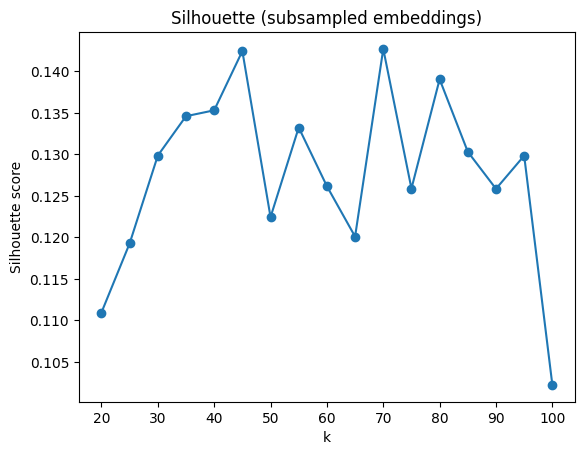

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from tqdm import tqdm

K_range = range(20, 101, 5)
sil_scores = []

for k in tqdm(K_range, desc="Evaluating k", unit="k"):
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=512,
        n_init=10
    )
    labels_k = km.fit_predict(X)
    score = silhouette_score(X, labels_k, metric="cosine")
    sil_scores.append(score)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(K_range, sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette (subsampled embeddings)")
plt.show()

In [ ]:
BEST_K = 35

final_km = MiniBatchKMeans(
    n_clusters=BEST_K,
    random_state=42,
    batch_size=1024,
    n_init=20
)

cluster_ids = final_km.fit_predict(X)

In [ ]:
clustered_labels = [
    {
        "label": label,
        "cluster": int(cid)
    }
    for label, cid in zip(labels, cluster_ids)
]

from collections import defaultdict

cluster_to_labels = defaultdict(list)

for item in clustered_labels:
    cluster_to_labels[item["cluster"]].append(item["label"])

In [ ]:
template_developer_prompt = """
System role: You are an expert financial analyst specializing in earnings call risk taxonomy and volatility drivers.

Task:
You will be given a list of topic labels that all belong to ONE cluster.
These labels are noisy, overlapping, and verbose.

Your job:
- Produce ONE short cluster label that tightly represents the shared concept.
- The primary focus must be on the underlying driver of market volatility.
- The label must be concise (3–6 words).
- Use financially precise, analyst-style language.
- Words used in the label must be highly relevant to each other, semantically aligned, and appropriate as a single concept.
- Avoid conjunction bloat and unnecessary modifiers.
- Prefer abstract drivers that explain volatility rather than operational detail.

Output format (STRICT):
Return a JSON object exactly as:
{"cluster_label": "<label>"}

Do not add any explanation.
"""

import math

BATCH_FILE = "cluster_label_batches.jsonl"
BATCH_SIZE = 1

clusters = list(cluster_to_labels.items())
# clusters = list(cluster_to_labels.items())[0:5]
num_batches = math.ceil(len(clusters) / BATCH_SIZE)

with open(BATCH_FILE, "w", encoding="utf-8") as f:
    for batch_idx in range(num_batches):
        start = batch_idx * BATCH_SIZE
        end = start + BATCH_SIZE
        batch_clusters = clusters[start:end]

        for cluster_id, labels in batch_clusters:
            labels_block = "\n".join(
                f"- {lbl}" for lbl in labels if lbl
            )

            user_prompt = f"""
Topic labels:
{labels_block}

Generate a single tight cluster label.
""".strip()

            body = {
                "model": "gpt-5.2",
                "reasoning": {"effort": "medium"},
                "instructions": template_developer_prompt,
                "input": user_prompt
            }

            entry = {
                "custom_id": f"cluster-{cluster_id}",
                "method": "POST",
                "url": "/v1/responses",
                "body": body
            }

            f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"Batch JSONL created: {BATCH_FILE}")
print(f"Total clusters: {len(clusters)}")

In [ ]:
import json
import time
from openai import OpenAI


upload = client.files.create(
    file=open(BATCH_FILE, "rb"),
    purpose="batch"
)

file_id = upload.id
print("Uploaded batch file:", file_id)

while True:
    status = client.files.retrieve(file_id).status
    print("File status:", status)
    if status == "processed":
        break
    time.sleep(3)




batch = client.batches.create(
    input_file_id=file_id,
    endpoint="/v1/responses",
    completion_window="24h"
)

batch_id = batch.id
print("Batch job created:", batch_id)

while True:
    info = client.batches.retrieve(batch_id)
    print(
        f"Batch status: {info.status} "
        f"({info.request_counts.completed}/{info.request_counts.total})"
    )

    if info.status == "completed":
        break
    if info.status in ("failed", "expired"):
        raise RuntimeError("Batch job failed or expired.")
    time.sleep(30)



output_file_id = info.output_file_id
result_file = client.files.content(output_file_id)
result_text = result_file.text

cluster_labels = {}
prompt_tokens_list = {}
completion_tokens_list = {}
reasoning_tokens_list = {}
total_tokens_list = {}

for line in result_text.splitlines():
    obj = json.loads(line)
    cid = obj["custom_id"]

    response = obj["response"]["body"]

    assistant_text = None
    for item in response.get("output", []):
        if item.get("type") == "message":
            content = item.get("content", [])
            if content and "text" in content[0]:
                assistant_text = content[0]["text"].strip()
            break

    try:
        parsed = json.loads(assistant_text)
        cluster_labels[cid] = parsed.get("cluster_label")
    except Exception:
        print(f"[WARN] {cid}: invalid JSON")
        cluster_labels[cid] = None

    usage = response.get("usage", {})
    prompt_tokens = usage.get("input_tokens", 0)
    completion_tokens = usage.get("output_tokens", 0)
    reasoning_tokens = usage.get("output_tokens_details", {}).get("reasoning_tokens", 0)
    total_tokens = prompt_tokens + completion_tokens

    prompt_tokens_list[cid] = prompt_tokens
    completion_tokens_list[cid] = completion_tokens
    reasoning_tokens_list[cid] = reasoning_tokens
    total_tokens_list[cid] = total_tokens

    print(
        f"ID {cid}: prompt={prompt_tokens}, completion={completion_tokens}, "
        f"reasoning={reasoning_tokens}, total={total_tokens}"
    )

In [ ]:
integrated_clusters = {}

for key, labels in clusters:
    cluster_key = str(key)
    label_key = f"cluster-{cluster_key}"

    integrated_clusters[cluster_key] = {
        "cluster_label": cluster_labels.get(label_key),
        "member_labels": labels
    }

import json


OUTPUT_FILE = "kefvp_train_maec_35clusters.json"

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(integrated_clusters, f, indent=2, ensure_ascii=False)

print(f"Saved {len(integrated_clusters)} clusters to {OUTPUT_FILE}")

In [1]:
import json

with open("/content/drive/MyDrive/Volatility-Prediction-Data/kefvp_train_maec_35clusters.json", "r", encoding="utf-8") as f:
    integrated_clusters = json.load(f)


In [2]:
import plotly.express as px

MAX_CLUSTERS = 10
MAX_MEMBERS_PER_CLUSTER = 6
FIG_WIDTH = 1200
FIG_HEIGHT = 1200

labels = []
parents = []

for cid, data in list(integrated_clusters.items())[10:MAX_CLUSTERS+10]:
    cluster_label = data["cluster_label"] or f"Cluster {cid}"

    labels.append(cluster_label)
    parents.append("")

    for m in data["member_labels"][:MAX_MEMBERS_PER_CLUSTER]:
        labels.append(m)
        parents.append(cluster_label)

fig = px.sunburst(
    names=labels,
    parents=parents
)

fig.update_layout(
    width=FIG_WIDTH,
    height=FIG_HEIGHT,
    margin=dict(t=20, l=0, r=0, b=0)
)

fig.show()

### Classify QAs to final clusters

In [ ]:
LABELS = []

for key, val in integrated_clusters.items():
    LABELS.append(val['cluster_label'])

template_developer_prompt = """
You are an expert financial NLP classifier.

Task:
- You will receive ONE question from an Earnings Call (ECC).
- You will also receive a fixed list of 35 labels.
- Assign the question to EXACTLY ONE label.
- Choose the single best semantic match.

Rules:
- Do NOT invent new labels.
- Do NOT return explanations.
- Output MUST be valid JSON.
- If multiple labels seem plausible, choose the closest primary intent.

Output format (STRICT):
{
  "label": "<ONE_LABEL_FROM_LIST>"
}
"""

In [ ]:
import json

datasets = [
    ("kefvp_train_maec15_label_batches.jsonl", kefvp_train_maec15_chunks_qas),
    ("kefvp_dev_maec15_label_batches.jsonl",   kefvp_dev_maec15_chunks_qas),
    ("kefvp_test_maec15_label_batches.jsonl",  kefvp_test_maec15_chunks_qas),
    ("kefvp_train_maec16_label_batches.jsonl", kefvp_train_maec16_chunks_qas),
    ("kefvp_dev_maec16_label_batches.jsonl",   kefvp_dev_maec16_chunks_qas),
    ("kefvp_test_maec16_label_batches.jsonl",  kefvp_test_maec16_chunks_qas),
]

for batch_file, chunks_qas in datasets:

    with open(batch_file, "w", encoding="utf-8") as f:

        for chunk_id, qas in chunks_qas.items():
            for q_idx, qa in enumerate(qas):

                question = qa["Q"]

                labels_block = "\n".join(
                    f"- {lbl}" for lbl in LABELS
                )

                user_prompt = f"""
Question:
"{question}"

Possible labels (choose ONE):
{labels_block}
""".strip()

                body = {
                    "model": "gpt-5-mini",
                    # "reasoning": {"effort": "medium"},
                    "instructions": template_developer_prompt,
                    "input": user_prompt,
                }

                entry = {
                    "custom_id": f"{chunk_id}-q{q_idx}",
                    "method": "POST",
                    "url": "/v1/responses",
                    "body": body,
                }

                f.write(json.dumps(entry, ensure_ascii=False) + "\n")

    print(f"Batch JSONL created: {batch_file}")

In [ ]:
import json
import os
import time

batch_files = [
    "kefvp_train_maec15_label_batches.jsonl",
    "kefvp_dev_maec15_label_batches.jsonl",
    "kefvp_test_maec15_label_batches.jsonl",
    "kefvp_train_maec16_label_batches.jsonl",
    "kefvp_dev_maec16_label_batches.jsonl",
    "kefvp_test_maec16_label_batches.jsonl",
]

all_results = {}

for batch_file in batch_files:

    print(f"\n{'='*80}")
    print(batch_file)
    print(f"{'='*80}")

    upload = client.files.create(
        file=open(batch_file, "rb"),
        purpose="batch"
    )

    file_id = upload.id
    print("Uploaded:", file_id)

    while True:
        status = client.files.retrieve(file_id).status
        print("File status:", status)
        if status == "processed":
            break
        time.sleep(3)

    batch = client.batches.create(
        input_file_id=file_id,
        endpoint="/v1/responses",
        completion_window="24h"
    )

    batch_id = batch.id
    print("Batch:", batch_id)

    while True:
        info = client.batches.retrieve(batch_id)

        print(
            f"Status: {info.status} "
            f"({info.request_counts.completed}/{info.request_counts.total})"
        )

        if info.status == "completed":
            break

        if info.status in ("failed", "expired", "cancelled"):
            raise RuntimeError(f"{batch_file} failed.")

        time.sleep(30)

    output_file_id = info.output_file_id
    result_text = client.files.content(output_file_id).text

    prompt_tokens_list = {}
    completion_tokens_list = {}
    reasoning_tokens_list = {}
    total_tokens_list = {}
    qa_labels = {}

    for line in result_text.splitlines():

        obj = json.loads(line)
        cid = obj["custom_id"]
        response = obj["response"]["body"]

        assistant_text = None
        for item in response.get("output", []):
            if item.get("type") == "message":
                content = item.get("content", [])
                if content and "text" in content[0]:
                    assistant_text = content[0]["text"].strip()
                break

        try:
            parsed = json.loads(assistant_text)
            qa_labels[cid] = parsed["label"]
        except Exception:
            print(f"[WARN] {cid}: invalid JSON")
            qa_labels[cid] = None

        usage = response.get("usage", {})

        prompt = usage.get("input_tokens", 0)
        completion = usage.get("output_tokens", 0)
        reasoning = usage.get("output_tokens_details", {}).get("reasoning_tokens", 0)
        total = prompt + completion

        prompt_tokens_list[cid] = prompt
        completion_tokens_list[cid] = completion
        reasoning_tokens_list[cid] = reasoning
        total_tokens_list[cid] = total

    all_results[batch_file] = {
        "batch_id": batch_id,
        "file_id": file_id,
        "qa_labels": qa_labels,
        "prompt_tokens": prompt_tokens_list,
        "completion_tokens": completion_tokens_list,
        "reasoning_tokens": reasoning_tokens_list,
        "total_tokens": total_tokens_list,
    }

    print(f"Finished {batch_file}")

In [ ]:
import json
import os

output_dir = ""

save_map = {
    "kefvp_train_maec15_label_batches.jsonl":
        "kefvp_train_maec15_qa_raw_final_label.json",

    "kefvp_dev_maec15_label_batches.jsonl":
        "kefvp_dev_maec15_qa_raw_final_label.json",

    "kefvp_test_maec15_label_batches.jsonl":
        "kefvp_test_maec15_qa_raw_final_label.json",

    "kefvp_train_maec16_label_batches.jsonl":
        "kefvp_train_maec16_qa_raw_final_label.json",

    "kefvp_dev_maec16_label_batches.jsonl":
        "kefvp_dev_maec16_qa_raw_final_label.json",

    "kefvp_test_maec16_label_batches.jsonl":
        "kefvp_test_maec16_qa_raw_final_label.json",

}

for batch_file, result in all_results.items():

    if batch_file not in save_map:
        continue

    out_name = save_map[batch_file]
    out_path = os.path.join(output_dir, out_name)

    qa_labels = result["qa_labels"]

    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(qa_labels, f, ensure_ascii=False, indent=2)

    print(f"Saved: {out_path}")

In [ ]:
# Reload the per-split classification results and sanity-check that every
# predicted label is one of the 35 known cluster labels.
import json

label_files = {
    "kefvp_train_maec15_chunks_qas": "kefvp_train_maec15_qa_raw_final_label.json",
    "kefvp_dev_maec15_chunks_qas": "kefvp_dev_maec15_qa_raw_final_label.json",
    "kefvp_test_maec15_chunks_qas": "kefvp_test_maec15_qa_raw_final_label.json",
    "kefvp_train_maec16_chunks_qas": "kefvp_train_maec16_qa_raw_final_label.json",
    "kefvp_dev_maec16_chunks_qas": "kefvp_dev_maec16_qa_raw_final_label.json",
    "kefvp_test_maec16_chunks_qas": "kefvp_test_maec16_qa_raw_final_label.json",
}

qa_raw_final_labels = {}

for var_name, filename in label_files.items():
    path = f"{filename}"
    with open(path, "r", encoding="utf-8") as f:
        labels_dict = json.load(f)
    qa_raw_final_labels[var_name] = labels_dict

    invalid = {qid: lbl for qid, lbl in labels_dict.items() if lbl not in LABELS}
    print(f"{var_name}: {len(labels_dict) - len(invalid)} valid / {len(invalid)} invalid labels")
    for qid, lbl in invalid.items():
        print(f"  [WARN] {qid}: {lbl!r} not in LABELS")

kefvp_train_maec15_qa_raw_final_label = qa_raw_final_labels["kefvp_train_maec15_chunks_qas"]
kefvp_dev_maec15_qa_raw_final_label = qa_raw_final_labels["kefvp_dev_maec15_chunks_qas"]
kefvp_test_maec15_qa_raw_final_label = qa_raw_final_labels["kefvp_test_maec15_chunks_qas"]
kefvp_train_maec16_qa_raw_final_label = qa_raw_final_labels["kefvp_train_maec16_chunks_qas"]
kefvp_dev_maec16_qa_raw_final_label = qa_raw_final_labels["kefvp_dev_maec16_chunks_qas"]
kefvp_test_maec16_qa_raw_final_label = qa_raw_final_labels["kefvp_test_maec16_chunks_qas"]

In [ ]:
for chunk_id, qas in kefvp_train_maec15_chunks_qas.items():
    for q_idx, qa in enumerate(qas):
        qid = f"{chunk_id}-q{q_idx}"
        qa["topic"] = kefvp_train_maec15_qa_raw_final_label.get(qid)

for chunk_id, qas in kefvp_dev_maec15_chunks_qas.items():
    for q_idx, qa in enumerate(qas):
        qid = f"{chunk_id}-q{q_idx}"
        qa["topic"] = kefvp_dev_maec15_qa_raw_final_label.get(qid)

for chunk_id, qas in kefvp_test_maec15_chunks_qas.items():
    for q_idx, qa in enumerate(qas):
        qid = f"{chunk_id}-q{q_idx}"
        qa["topic"] = kefvp_test_maec15_qa_raw_final_label.get(qid)


for chunk_id, qas in kefvp_train_maec16_chunks_qas.items():
    for q_idx, qa in enumerate(qas):
        qid = f"{chunk_id}-q{q_idx}"
        qa["topic"] = kefvp_train_maec16_qa_raw_final_label.get(qid)

for chunk_id, qas in kefvp_dev_maec16_chunks_qas.items():
    for q_idx, qa in enumerate(qas):
        qid = f"{chunk_id}-q{q_idx}"
        qa["topic"] = kefvp_dev_maec16_qa_raw_final_label.get(qid)

for chunk_id, qas in kefvp_test_maec16_chunks_qas.items():
    for q_idx, qa in enumerate(qas):
        qid = f"{chunk_id}-q{q_idx}"
        qa["topic"] = kefvp_test_maec16_qa_raw_final_label.get(qid)

In [ ]:
import json
import os

OUTPUT_DIR = ""

datasets = {
    "kefvp_train_maec15_chunks_qas_with_final_label.json": kefvp_train_maec15_chunks_qas,
    "kefvp_dev_maec15_chunks_qas_with_final_label.json": kefvp_dev_maec15_chunks_qas,
    "kefvp_test_maec15_chunks_qas_with_final_label.json": kefvp_test_maec15_chunks_qas,
    "kefvp_train_maec16_chunks_qas_with_final_label.json": kefvp_train_maec16_chunks_qas,
    "kefvp_dev_maec16_chunks_qas_with_final_label.json": kefvp_dev_maec16_chunks_qas,
    "kefvp_test_maec16_chunks_qas_with_final_label.json": kefvp_test_maec16_chunks_qas,
}

for filename, data in datasets.items():
    output_file = os.path.join(OUTPUT_DIR, filename)
    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    print(f"Saved {len(data)} chunks to {output_file}")

Mounted at /content/drive


##### EC

In [ ]:
import json

with open("ec_kefvp_test_clean_chunks_qas_results.json", "r", encoding="utf-8") as f:
    kefvp_test_ec_chunks_qas = json.load(f)

In [ ]:
import json

datasets = [
    ("kefvp_test_ec_label_batches.jsonl", kefvp_test_ec_chunks_qas),
]

for batch_file, chunks_qas in datasets:

    with open(batch_file, "w", encoding="utf-8") as f:

        for chunk_id, qas in chunks_qas.items():
            for q_idx, qa in enumerate(qas):

                question = qa["Q"]

                labels_block = "\n".join(
                    f"- {lbl}" for lbl in LABELS
                )

                user_prompt = f"""
Question:
"{question}"

Possible labels (choose ONE):
{labels_block}
""".strip()

                body = {
                    "model": "gpt-5-mini",
                    # "reasoning": {"effort": "medium"},
                    "instructions": template_developer_prompt,
                    "input": user_prompt,
                }

                entry = {
                    "custom_id": f"{chunk_id}-q{q_idx}",
                    "method": "POST",
                    "url": "/v1/responses",
                    "body": body,
                }

                f.write(json.dumps(entry, ensure_ascii=False) + "\n")

    print(f"Batch JSONL created: {batch_file}")

In [ ]:
import json
import os
import time

batch_files = [
    "kefvp_test_ec_label_batches.jsonl",
]

all_results = {}

for batch_file in batch_files:

    print(f"\n{'='*80}")
    print(batch_file)
    print(f"{'='*80}")

    upload = client.files.create(
        file=open(batch_file, "rb"),
        purpose="batch"
    )

    file_id = upload.id
    print("Uploaded:", file_id)

    while True:
        status = client.files.retrieve(file_id).status
        print("File status:", status)
        if status == "processed":
            break
        time.sleep(3)

    batch = client.batches.create(
        input_file_id=file_id,
        endpoint="/v1/responses",
        completion_window="24h"
    )

    batch_id = batch.id
    print("Batch:", batch_id)

    while True:
        info = client.batches.retrieve(batch_id)

        print(
            f"Status: {info.status} "
            f"({info.request_counts.completed}/{info.request_counts.total})"
        )

        if info.status == "completed":
            break

        if info.status in ("failed", "expired", "cancelled"):
            raise RuntimeError(f"{batch_file} failed.")

        time.sleep(30)

    output_file_id = info.output_file_id
    result_text = client.files.content(output_file_id).text

    prompt_tokens_list = {}
    completion_tokens_list = {}
    reasoning_tokens_list = {}
    total_tokens_list = {}
    qa_labels = {}

    for line in result_text.splitlines():

        obj = json.loads(line)
        cid = obj["custom_id"]
        response = obj["response"]["body"]

        assistant_text = None
        for item in response.get("output", []):
            if item.get("type") == "message":
                content = item.get("content", [])
                if content and "text" in content[0]:
                    assistant_text = content[0]["text"].strip()
                break

        try:
            parsed = json.loads(assistant_text)
            qa_labels[cid] = parsed["label"]
        except Exception:
            print(f"[WARN] {cid}: invalid JSON")
            qa_labels[cid] = None

        usage = response.get("usage", {})

        prompt = usage.get("input_tokens", 0)
        completion = usage.get("output_tokens", 0)
        reasoning = usage.get("output_tokens_details", {}).get("reasoning_tokens", 0)
        total = prompt + completion

        prompt_tokens_list[cid] = prompt
        completion_tokens_list[cid] = completion
        reasoning_tokens_list[cid] = reasoning
        total_tokens_list[cid] = total

    all_results[batch_file] = {
        "batch_id": batch_id,
        "file_id": file_id,
        "qa_labels": qa_labels,
        "prompt_tokens": prompt_tokens_list,
        "completion_tokens": completion_tokens_list,
        "reasoning_tokens": reasoning_tokens_list,
        "total_tokens": total_tokens_list,
    }

    print(f"Finished {batch_file}")

In [ ]:
import json
import os

output_dir = ""

save_map = {
    "kefvp_test_ec_label_batches.jsonl":
        "kefvp_test_ec_qa_raw_final_label.json",
}

for batch_file, result in all_results.items():

    if batch_file not in save_map:
        continue

    out_name = save_map[batch_file]
    out_path = os.path.join(output_dir, out_name)

    qa_labels = result["qa_labels"]

    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(qa_labels, f, ensure_ascii=False, indent=2)

    print(f"Saved: {out_path}")

import json

with open("kefvp_test_ec_qa_raw_final_label.json", "r", encoding="utf-8") as f:
    kefvp_test_ec_qa_raw_final_label = json.load(f)

In [ ]:
invalid_labels = {}
valid_count = 0

for qid, label in kefvp_test_ec_qa_raw_final_label.items():
    if label in LABELS:
        valid_count += 1
    else:
        invalid_labels[qid] = label

print(f"Valid labels: {valid_count}")
print(f"Invalid labels: {len(invalid_labels)}")

In [ ]:
for chunk_id, qas in kefvp_test_ec_chunks_qas.items():
    for q_idx, qa in enumerate(qas):
        qid = f"{chunk_id}-q{q_idx}"
        qa["topic"] = kefvp_test_ec_qa_raw_final_label.get(qid)

import json
import os

OUTPUT_DIR = ""

datasets = {
    "kefvp_test_ec_chunks_qas_with_final_label.json": kefvp_test_ec_chunks_qas,
}

for filename, data in datasets.items():
    output_file = os.path.join(OUTPUT_DIR, filename)
    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    print(f"Saved {len(data)} chunks to {output_file}")

## Add Text Lines and Audio Map to QA Chunks (max_lines=100)

Re-chunks each transcript (same `split_ecc_into_chunks` used in Section 3) and attaches the resulting `text_lines`/`audio_map` to every labeled QA chunk, then writes the final per-split JSON files.  

##### MAEC

In [ ]:
# split_ecc_into_chunks is defined in generate question section
maec_all_ecc_chunks = []

for idx, row in maec_transcripts_df.iterrows():
    transcript = row["annotated_transcript_text"]
    turn_audio_map = row["turn_audio_map"]

    chunks = split_ecc_into_chunks(transcript, turn_audio_map, max_lines=100)
    maec_all_ecc_chunks.append({
        "ecc_id": idx,
        "chunks": chunks
    })

In [ ]:
datasets = {
    "kefvp_train_maec15_chunks_qas": kefvp_train_maec15_chunks_qas,
    "kefvp_dev_maec15_chunks_qas": kefvp_dev_maec15_chunks_qas,
    "kefvp_test_maec15_chunks_qas": kefvp_test_maec15_chunks_qas,
    "kefvp_train_maec16_chunks_qas": kefvp_train_maec16_chunks_qas,
    "kefvp_dev_maec16_chunks_qas": kefvp_dev_maec16_chunks_qas,
    "kefvp_test_maec16_chunks_qas": kefvp_test_maec16_chunks_qas,
}

for name, dataset in datasets.items():
    new_dataset = {}

    for key, qas in dataset.items():
        ecc_id_str, chunk_id_str = key.split("-")
        ecc_id = int(ecc_id_str)
        chunk_id = int(chunk_id_str)

        chunk_data = maec_all_ecc_chunks[ecc_id]["chunks"][chunk_id]

        new_dataset[key] = {
            "qas": qas,
            "text_lines": chunk_data.get("text_lines"),
            "audio_map": chunk_data.get("audio_map"),
            "audio_path": maec_transcripts_df.iloc[ecc_id]["audio_path"],
        }

    datasets[name] = new_dataset

kefvp_train_maec15_chunks_qas = datasets["kefvp_train_maec15_chunks_qas"]
kefvp_dev_maec15_chunks_qas = datasets["kefvp_dev_maec15_chunks_qas"]
kefvp_test_maec15_chunks_qas = datasets["kefvp_test_maec15_chunks_qas"]
kefvp_train_maec16_chunks_qas = datasets["kefvp_train_maec16_chunks_qas"]
kefvp_dev_maec16_chunks_qas = datasets["kefvp_dev_maec16_chunks_qas"]
kefvp_test_maec16_chunks_qas = datasets["kefvp_test_maec16_chunks_qas"]

In [ ]:
import json
import os

OUTPUT_DIR = ""

datasets = {
    "kefvp_train_maec15_chunks_qas_with_final_label_with_textlines_with_audiomap.json": kefvp_train_maec15_chunks_qas,
    "kefvp_dev_maec15_chunks_qas_with_final_label_with_textlines_with_audiomap.json": kefvp_dev_maec15_chunks_qas,
    "kefvp_test_maec15_chunks_qas_with_final_label_with_textlines_with_audiomap.json": kefvp_test_maec15_chunks_qas,
    "kefvp_train_maec16_chunks_qas_with_final_label_with_textlines_with_audiomap.json": kefvp_train_maec16_chunks_qas,
    "kefvp_dev_maec16_chunks_qas_with_final_label_with_textlines_with_audiomap.json": kefvp_dev_maec16_chunks_qas,
    "kefvp_test_maec16_chunks_qas_with_final_label_with_textlines_with_audiomap.json": kefvp_test_maec16_chunks_qas,
}

for filename, data in datasets.items():
    output_file = os.path.join(OUTPUT_DIR, filename)

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    print(f"Saved {len(data)} chunks to {output_file}")

##### EC

In [ ]:
# Fix wrong audio paths
for key, item in kefvp_test_ec_chunks_qas.items():
    idx = int(key.split("-")[0])
    item["audio_path"] = ec_transcripts_test_df.iloc[idx]["audio_path"]


INPUT_DIR = ""

with open(
    os.path.join(INPUT_DIR, "kefvp_test_ec_chunks_qas_with_final_label.json"),
    "w",
    encoding="utf-8",
) as f:
    json.dump(kefvp_test_ec_chunks_qas, f, ensure_ascii=False, indent=2)

In [ ]:
# split_ecc_into_chunks is defined in generate question section
ec_all_ecc_chunks = []

for idx, row in ec_transcripts_test_df.iterrows():
    transcript = row["annotated_transcript_text"]
    turn_audio_map = row["turn_audio_map"]

    chunks = split_ecc_into_chunks(transcript, turn_audio_map, max_lines=100)
    ec_all_ecc_chunks.append({
        "ecc_id": idx,
        "chunks": chunks
    })

datasets = {
    "kefvp_test_ec_chunks_qas": kefvp_test_ec_chunks_qas,
}

for name, dataset in datasets.items():
    new_dataset = {}

    for key, qas in dataset.items():
        ecc_id_str, chunk_id_str = key.split("-")
        ecc_id = int(ecc_id_str)
        chunk_id = int(chunk_id_str)

        chunk_data = ec_all_ecc_chunks[ecc_id]["chunks"][chunk_id]

        new_dataset[key] = {
            "qas": qas,
            "text_lines": chunk_data.get("text_lines"),
            "audio_map": chunk_data.get("audio_map"),
            "audio_path": ec_transcripts_test_df.iloc[ecc_id]["audio_path"],
        }

    datasets[name] = new_dataset

kefvp_test_ec_chunks_qas = datasets["kefvp_test_ec_chunks_qas"]

In [ ]:
# remove nested dics
for item in kefvp_test_ec_chunks_qas.values():
    item["qas"] = item["qas"]["qas"]

In [ ]:
import json
import os

OUTPUT_DIR = "/content/drive/MyDrive/Volatility-Prediction-Data"

datasets = {
    "kefvp_test_ec_chunks_qas_with_final_label_with_textlines_with_audiomap.json": kefvp_test_ec_chunks_qas,
}

for filename, data in datasets.items():
    output_file = os.path.join(OUTPUT_DIR, filename)

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    print(f"Saved {len(data)} chunks to {output_file}")